In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path



In [21]:
# ACQUIRE: Read the supplied file and verify the structure.
df = pd.read_csv("downloads/heart disease.csv")
print("Dataset shape:", df.shape)
print(df.head())
df.info()
print(df.describe())

Dataset shape: (918, 12)
   Age Sex ChestPainType  RestingBP  Cholesterol  FastingBS RestingECG  MaxHR  \
0   40   M           ATA        140          289          0     Normal    172   
1   49   F           NAP        160          180          0     Normal    156   
2   37   M           ATA        130          283          0         ST     98   
3   48   F           ASY        138          214          0     Normal    108   
4   54   M           NAP        150          195          0     Normal    122   

  ExerciseAngina  Oldpeak ST_Slope  HeartDisease  
0              N      0.0       Up             0  
1              N      1.0     Flat             1  
2              N      0.0       Up             0  
3              Y      1.5     Flat             1  
4              N      0.0       Up             0  
<class 'pandas.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  ----- 

In [4]:
# Review all categorical levels and validate expected binary encodings.
for column in ["Sex", "ChestPainType", "RestingECG", "ExerciseAngina", "ST_Slope", "FastingBS", "HeartDisease"]:
    print(f"\n{column} levels:\n", df[column].value_counts(dropna=False))
for column in ["FastingBS", "HeartDisease"]:
    print(column, "contains only 0 and 1:", bool(np.isin(df[column].to_numpy(), [0, 1]).all()))


Sex levels:
 Sex
M    725
F    193
Name: count, dtype: int64

ChestPainType levels:
 ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

RestingECG levels:
 RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

ExerciseAngina levels:
 ExerciseAngina
N    547
Y    371
Name: count, dtype: int64

ST_Slope levels:
 ST_Slope
Flat    460
Up      395
Down     63
Name: count, dtype: int64

FastingBS levels:
 FastingBS
0    704
1    214
Name: count, dtype: int64

HeartDisease levels:
 HeartDisease
1    508
0    410
Name: count, dtype: int64
FastingBS contains only 0 and 1: True
HeartDisease contains only 0 and 1: True


In [5]:
# Investigate possible coded missing values; retain originals and flag them.
prepared_df = df.copy()
prepared_df["RestingBP_zero_flag"] = prepared_df["RestingBP"].eq(0)
prepared_df["Cholesterol_zero_flag"] = prepared_df["Cholesterol"].eq(0)
prepared_df["Oldpeak_negative_flag"] = prepared_df["Oldpeak"].lt(0)
for flag in ["RestingBP_zero_flag", "Cholesterol_zero_flag", "Oldpeak_negative_flag"]:
    print(flag, int(np.sum(prepared_df[flag].to_numpy())))

RestingBP_zero_flag 1
Cholesterol_zero_flag 172
Oldpeak_negative_flag 13


In [6]:
# Summarize class balance and calculate percentages.
target_counts = prepared_df["HeartDisease"].value_counts().sort_index()
print(pd.DataFrame({"Count": target_counts, "Percent": (100 * target_counts / len(prepared_df)).round(1)}))

              Count  Percent
HeartDisease                
0               410     44.7
1               508     55.3


In [10]:
# IQR screening flags potential outliers, not necessarily errors.
cols = ["Age", "RestingBP", "Cholesterol", "MaxHR", "Oldpeak"]
data = prepared_df[cols]

q1 = data.quantile(0.25)
q3 = data.quantile(0.75)
iqr = q3 - q1

outlier_counts = ((data < q1 - 1.5 * iqr) | (data > q3 + 1.5 * iqr)).sum()

print("IQR potential outliers per column:")
print(outlier_counts.to_string())

IQR potential outliers per column:
Age              0
RestingBP       28
Cholesterol    183
MaxHR            2
Oldpeak         16


In [12]:
# ANALYZE: Outcome proportions within categories (not raw counts alone).
cat_cols = ["ChestPainType", "ExerciseAngina", "ST_Slope", "Sex"]

long_df = prepared_df.melt(
    id_vars="HeartDisease",
    value_vars=cat_cols,
    var_name="feature",
    value_name="category",
)

summary = long_df.groupby(["feature", "category"])["HeartDisease"].agg(
    n="size", outcome_rate="mean"
)
summary["outcome_rate"] = (summary["outcome_rate"] * 100).round(1)

print("Outcome percentage by category:\n", summary)
print("\nMedian numerical values by outcome:\n",
      prepared_df.groupby("HeartDisease")[["Age", "MaxHR", "Oldpeak"]].median())

Outcome percentage by category:
                            n  outcome_rate
feature        category                   
ChestPainType  ASY       496          79.0
               ATA       173          13.9
               NAP       203          35.5
               TA         46          43.5
ExerciseAngina N         547          35.1
               Y         371          85.2
ST_Slope       Down       63          77.8
               Flat      460          82.8
               Up        395          19.7
Sex            F         193          25.9
               M         725          63.2

Median numerical values by outcome:
                Age  MaxHR  Oldpeak
HeartDisease                      
0             51.0  150.0      0.0
1             57.0  126.0      1.2


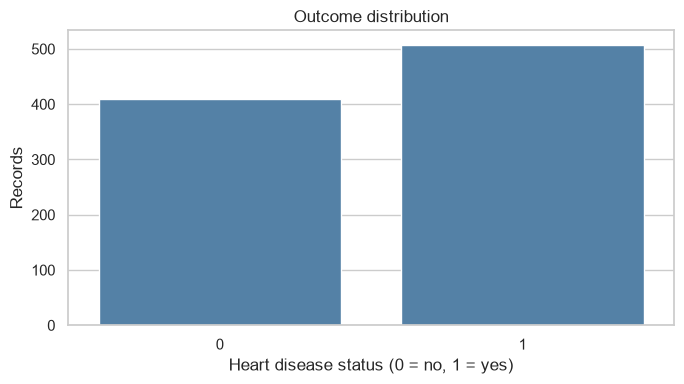

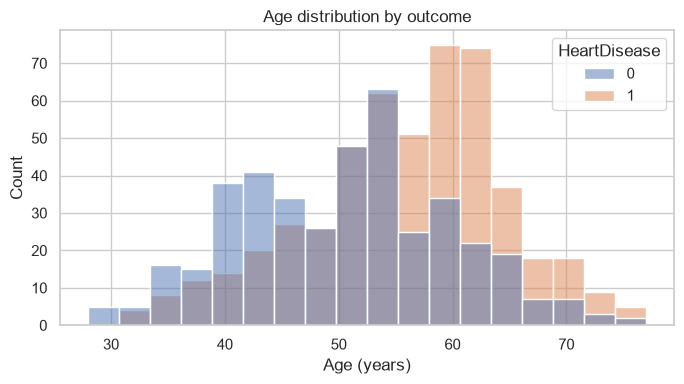

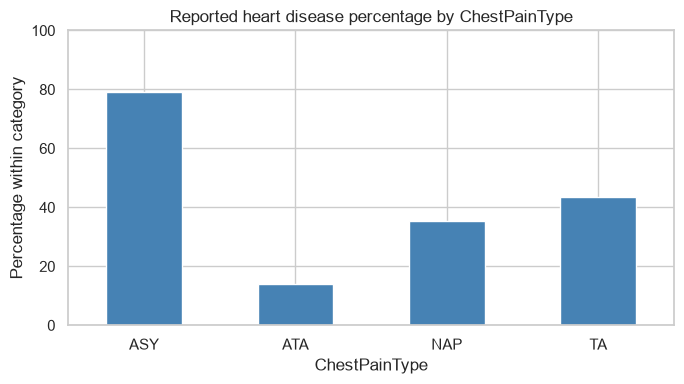

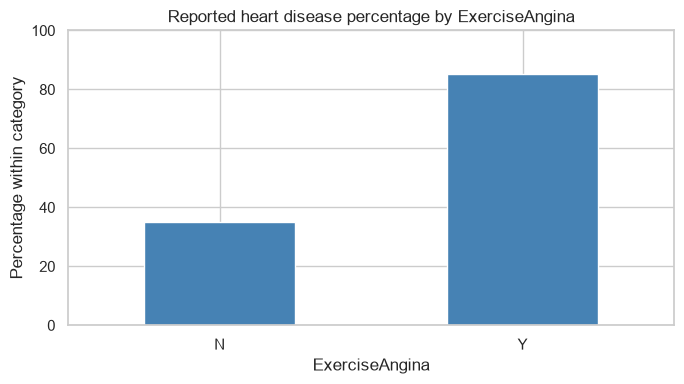

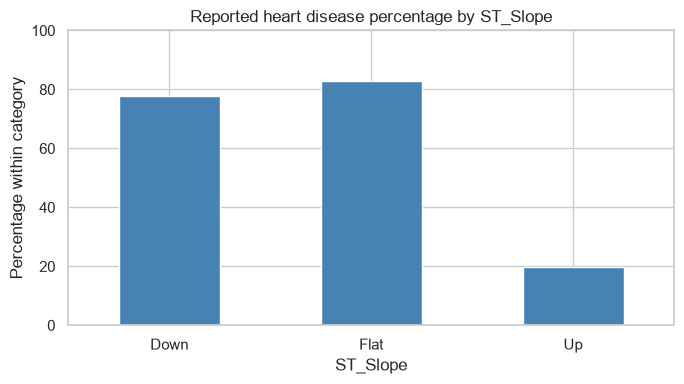

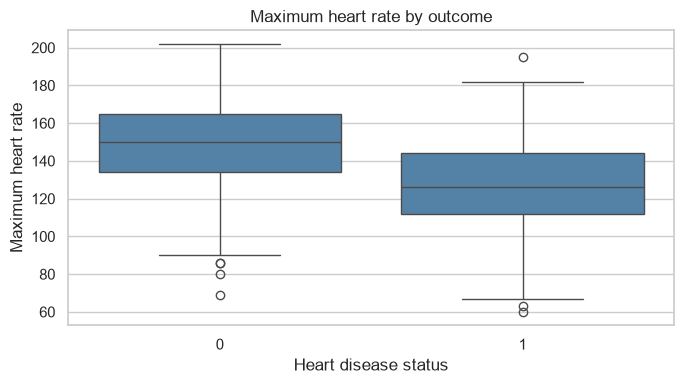

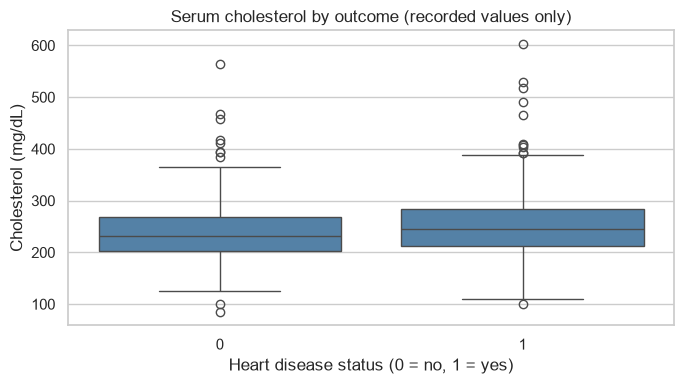

In [22]:
%matplotlib inline

# REPORT: Export charts for use in the slides and report.
def save(fig, filename):
    fig.tight_layout()
    fig.savefig(OUTPUT / filename, dpi=180)
    plt.show()

def rate_chart(column, filename):
    rates = 100 * prepared_df.groupby(column)["HeartDisease"].mean()
    fig, ax = plt.subplots(figsize=(7, 4))
    rates.plot.bar(ax=ax, color="steelblue")
    ax.set(title=f"Reported heart disease percentage by {column}",
           xlabel=column, ylabel="Percentage within category", ylim=(0, 100))
    ax.tick_params(axis="x", rotation=0)
    save(fig, filename)

# 1. Outcome distribution
fig, ax = plt.subplots(figsize=(7, 4))
sns.countplot(data=prepared_df, x="HeartDisease", order=[0, 1], color="steelblue", ax=ax)
ax.set(xlabel="Heart disease status (0 = no, 1 = yes)", ylabel="Records", title="Outcome distribution")
save(fig, "01_target.png")

# 2. Age by outcome
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=prepared_df, x="Age", hue="HeartDisease", bins=18, multiple="layer",
             alpha=.5, palette="deep", ax=ax)
ax.set(title="Age distribution by outcome", xlabel="Age (years)")
save(fig, "02_age.png")

# 3–5. Outcome rate by category
rate_chart("ChestPainType", "03_ChestPainType.png")
rate_chart("ExerciseAngina", "04_ExerciseAngina.png")
rate_chart("ST_Slope", "05_ST_Slope.png")

# 6. Max heart rate by outcome
fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=prepared_df, x="HeartDisease", y="MaxHR", order=[0, 1], color="steelblue", ax=ax)
ax.set(title="Maximum heart rate by outcome", xlabel="Heart disease status", ylabel="Maximum heart rate")
save(fig, "06_maxhr.png")

# 7. Cholesterol by outcome
chol_df = prepared_df[prepared_df["Cholesterol"] > 0]   # drop 0 = missing (see note)

fig, ax = plt.subplots(figsize=(7, 4))
sns.boxplot(data=chol_df, x="HeartDisease", y="Cholesterol", order=[0, 1], color="steelblue", ax=ax)
ax.set(title="Serum cholesterol by outcome (recorded values only)",
       xlabel="Heart disease status (0 = no, 1 = yes)", ylabel="Cholesterol (mg/dL)")
save(fig, "07_cholesterol.png")